# 层次聚类实战：商场客户细分

本案例将演示如何使用层次聚类（Hierarchical Clustering）算法对商场客户进行细分。我们将使用模拟的“年收入”与“消费分数”数据，通过树状图（Dendrogram）分析客户群体的层级结构，并最终划分出具有商业价值的客户类别。

## 1. 场景背景

假设你是某商场的市场总监，你拥有客户的会员卡数据，其中包括两个核心指标：
- **年收入 (Annual Income, k$)**：客户的经济能力。
- **消费分数 (Spending Score, 1-100)**：商场根据客户的消费行为和频率计算出的评分。

你的目标是将客户划分为不同的群体（Clusters），以便制定差异化的营销策略。

## 2. 数据准备与可视化

前 5 条数据示例：
   Annual Income (k$)  Spending Score (1-100)
0           13.829233               13.829315
1           17.483571               14.308678
2           12.682912               12.671351
3           11.996807               13.541531
4           16.044318                5.201649


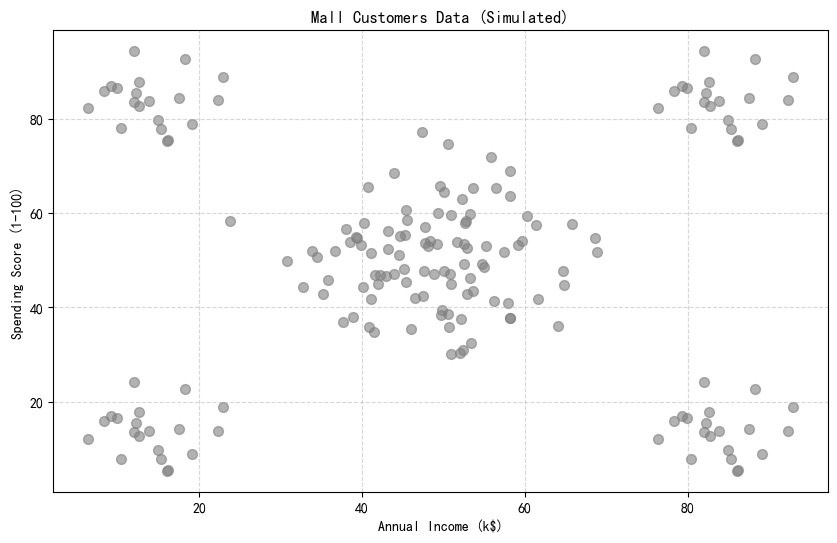

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs

# 设置随机种子以保证结果可复现
np.random.seed(42)

# 生成模拟数据：5 个典型的客户群体
# 1. 节俭型 (Sensible): 低收入，低消费
# 2. 享乐型 (Careless): 低收入，高消费
# 3. 吝啬型 (Miser): 高收入，低消费
# 4. 目标型 (Target): 高收入，高消费
# 5. 标准型 (Standard): 中等收入，中等消费

X_1, _ = make_blobs(n_samples=20, centers=[[15, 15]], cluster_std=5, random_state=42)
X_2, _ = make_blobs(n_samples=20, centers=[[15, 85]], cluster_std=5, random_state=42)
X_3, _ = make_blobs(n_samples=20, centers=[[85, 15]], cluster_std=5, random_state=42)
X_4, _ = make_blobs(n_samples=20, centers=[[85, 85]], cluster_std=5, random_state=42)
X_5, _ = make_blobs(n_samples=100, centers=[[50, 50]], cluster_std=10, random_state=42)

X = np.vstack([X_1, X_2, X_3, X_4, X_5])

# 转换为 DataFrame 方便查看
df = pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
print("前 5 条数据示例：")
print(df.head())

# 可视化原始数据
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray', alpha=0.6)
plt.title('Mall Customers Data (Simulated)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. 使用树状图 (Dendrogram) 确定聚类数

层次聚类的一个巨大优势是可以生成树状图。树状图展示了簇合并的顺序和距离。通过观察树状图，我们可以直观地决定最佳的聚类数量 $K$。

- 纵轴表示簇合并时的**距离**（Euclidean Distance）。
- 我们通常寻找**最长的垂直线段**，这条线段没有被横向的水平线穿过。在这条线段的中间画一条水平线，其与垂直线的交点数量就是推荐的聚类数。

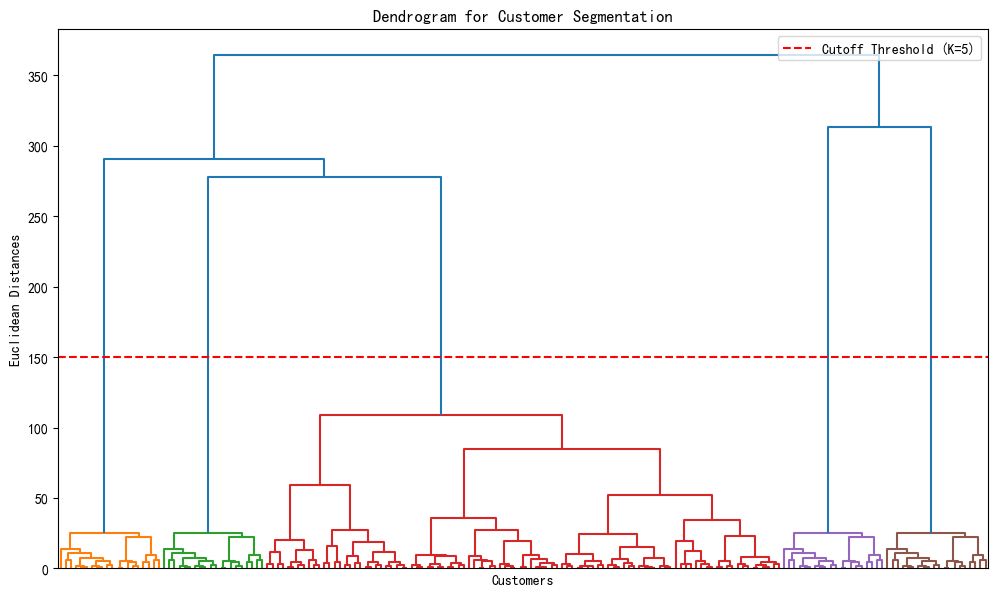

In [2]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12, 7))
plt.title('Dendrogram for Customer Segmentation')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')

# 使用 Ward 连接法，因为它倾向于产生大小均匀、紧凑的簇，非常适合这种分布的数据
# sch.linkage 会计算距离矩阵并生成聚类树
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'), no_labels=True)

# 绘制一条红线作为阈值参考
# 从图中可以看出，在距离约为 150 到 250 之间有一段很长的垂直距离
plt.axhline(y=150, color='r', linestyle='--', label='Cutoff Threshold (K=5)')
plt.legend()
plt.show()

## 4. 训练层次聚类模型

根据树状图的分析结果，我们将聚类数设置为 $K=5$，并使用 `AgglomerativeClustering` 进行建模。

In [3]:
from sklearn.cluster import AgglomerativeClustering

# 创建模型
# n_clusters=5: 也就是我们在树状图中选定的 K 值
# linkage='ward': 最小化簇内方差
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')

# 训练并预测
y_hc = hc.fit_predict(X)

print("聚类标签示例:", y_hc[:10])

聚类标签示例: [3 3 3 3 3 3 3 3 3 3]


## 5. 结果可视化与分析

最后，我们将聚类结果可视化，看看模型是否成功识别出了我们预设的 5 个客户群体。

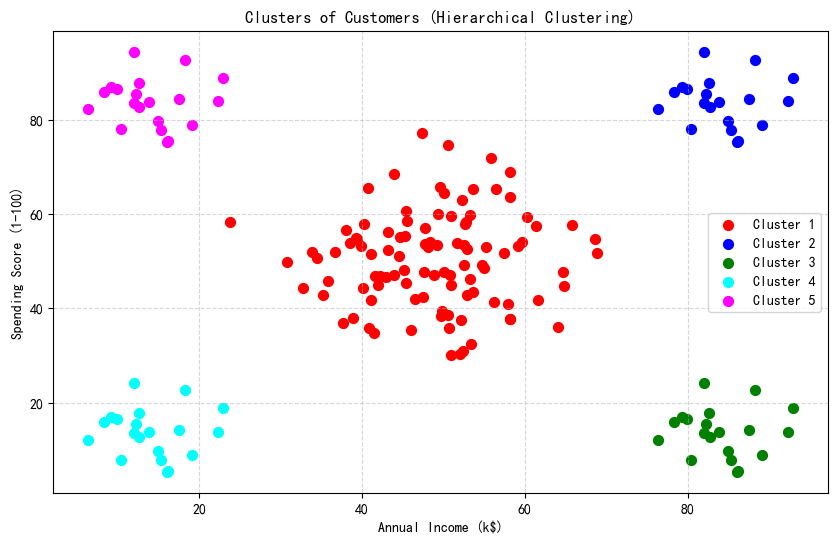

In [4]:
plt.figure(figsize=(10, 6))

# 绘制 5 个簇
# 注意：聚类标签 0-4 的顺序可能与我们生成的顺序不一致，这是正常的
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(5):
    plt.scatter(X[y_hc == i, 0], X[y_hc == i, 1], s=50, c=colors[i], label=labels[i])

plt.title('Clusters of Customers (Hierarchical Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. 结论

通过层次聚类，我们成功地将客户划分为 5 个具有明显特征的群体。这种分析可以帮助市场部门制定针对性的策略：

- **高收入高消费群（Target）**：VIP 客户，推荐高端产品和专属服务。
- **高收入低消费群（Miser）**：潜力客户，需要通过促销或精准广告激发其消费欲望。
- **中等收入中等消费群（Standard）**：大众客户，维持现有服务，提供会员积分等留存策略。

相比于 K-Means，层次聚类的优势在于**不需要预先假设 K 值**，而是通过树状图提供了一个可视化的决策过程。